---
title: "Re-assembly Starting Communities"
author: "Afra Salazar and Sara Mitri"
date: "August 2026"
format: 
  html:
    self-contained: true
    fig-dpi: 400
    theme: cosmo
    fontsize: 1.1rem
    linestretch: 1.4
    linkcolor: "#82a6b3"
    mainfont: "Source Sans Pro"
    
    # Code
    highlight-style: arrow (light)
    code-fold: true
    code-summary: "Show the code"
toc: true
jupyter: Julia
---

In [1]:
#| code-summary: "Loading necessary libraries and packages"

using DataFrames, CSV, Gadfly, StatsBase, Statistics, Cairo, Fontconfig, JLD2, LinearAlgebra, Colors, Distributions, HypothesisTests
include("Colours.jl") ;

In [2]:
#| code-summary: "Custom functions"

function plotMotherOffspringScores(MCombinations, mother)
    
    mo = MCombinations[findall(x -> x == "com$(mother)", MCombinations.MotherID), :]
    push!(mo, MCombinations[mother, :])
    
    
    p = plot(x = 1:length(mo.CommunityScore), 
                y = mo.CommunityScore, 
                color = mo.MotherID, 
                Geom.point,
                alpha = [0.8],
                size = [2mm], 
    
                Guide.xticks(ticks = []),
                Guide.yticks(ticks = [-0.4, -.2, 0, 0.2, 0.4]),
                Guide.xlabel("Com$(mother)"),
                Guide.ylabel("Community score"),

                #Guide.title("com$(mother)"),
    
                Scale.color_discrete_manual("#ED71AA", "#223F5D", "#D6D6D6",),
                Theme(highlight_width = 0.5pt, continuous_highlight_color = _ -> "white", key_position = :none))
    return p
end


function findSelected(ϕN0, ϕN1)
    repro = unique(ϕN1.MotherID)
    v = []
    for com in ϕN0.CommunityID
        if com in repro
            push!(v, "Selected")
        else
            push!(v, "NS")
        end
    end
    
    return v
end

function mutationDistance(A, B)
    onlyA = length(setdiff(A, B))
    onlyB = length(setdiff(B, A))
    return max(onlyA, onlyB)
end

;

### Upload community scores (results from the experiments)

In [3]:
#| code-summary: "Upload files"

ϕR0 = CSV.read("2025.05.17_METACommunity_Round-0_w_FD.csv", DataFrame)
ϕR1 = CSV.read("2025.05.21_METACommunity_Round-1-AFTER.csv", DataFrame)
ϕR2 = CSV.read("2025.06.04_METACommunity_Round-2-AFTER.csv", DataFrame)
ϕR3 = CSV.read("2025.08.21_METACommunity_Round-3-AFTER.csv", DataFrame)
ϕR4 = CSV.read("2025.08.28_METACommunity_Round-4-AFTER.csv", DataFrame)
ϕR5 = CSV.read("2025.11.14_METACommunity_Round-5-AFTER.csv", DataFrame)
METACombinations = CSV.read("METACommunityPool_ManualR5.csv", DataFrame)
;

In [4]:
#| code-summary: "Characterise communities"

#Remove motherless communities (MotherID = "com0")
motherCommunities = filter(:MotherID => x -> x != "com0", METACombinations)

#Compute mean offspring score per mother community
offspring_avg = combine(groupby(motherCommunities, :MotherID), :CommunityScore => mean => :OffspringAvgScore)

#Rename MotherID → CommunityID so we can join
rename!(offspring_avg, :MotherID => :CommunityID)

#Get each mother's own score
mother_scores = METACombinations[:, [:CommunityID, :CommunityScore]]

#Join offspring averages with mother scores
plotdf = innerjoin(mother_scores, offspring_avg, on = :CommunityID)
rename!(plotdf, :CommunityScore => :MotherScore) 

#Get number of offspring per mother community 
mcounts = []
for mother in METACombinations.CommunityID
    a = findall(x -> x == mother, METACombinations.MotherID)
    push!(mcounts, length(a))
end 

METACombinations.LRS = mcounts


#Get community richness
lenComms = length.([Set(parse.(Int, strip.(split(s, ',')))) for s in METACombinations.Members]) ;

In [5]:
#| code-summary: "Get selected communities"

#Get selected communities for Round 5 (Algorithm 2)
metacommother = []
for com in ϕR5.MotherID
    metacomindex = findall(x -> x == com, METACombinations.CommunityID)
    push!(metacommother, metacomindex)
end

metacommother = vcat(metacommother...) 
METACombinations.SelectedforR5 = repeat(["NS"], length(METACombinations[:, 1])) 
METACombinations.SelectedforR5[metacommother] .= "Selected" 

#Get selected communities with Algorithm 1
ϕR0ϕR1 = findSelected(ϕR0, ϕR1)
ϕR1ϕR2 = findSelected(ϕR1, ϕR2)
ϕR2ϕR3 = findSelected(ϕR2, ϕR3)
ϕR3ϕR4 = findSelected(ϕR3, ϕR4)
ϕR4Y = repeat(["NS"], 63)
ϕR5Y = repeat(["NS"], 63)

sColouring = hcat(ϕR0ϕR1, ϕR1ϕR2, ϕR2ϕR3, ϕR3ϕR4, ϕR4Y, ϕR5Y)

A = hcat(ϕR0.CommunityScore, ϕR1.CommunityScore, ϕR2.CommunityScore, ϕR3.CommunityScore, ϕR4.CommunityScore, ϕR5.CommunityScore)
B = hcat(ϕR0.FunIntegration, ϕR1.FunIntegration, ϕR2.FunIntegration, ϕR3.FunIntegration, ϕR4.FunIntegration, ϕR5.FunIntegration)

#Create column names for each replicate
ncols = size(A, 2)
colnames = ["R$(i-1)" for i in 1:ncols]

#Create DataFrame
df = DataFrame(A, Symbol.(colnames))

#Convert to long format for plotting
selectedOne = stack(df, Not([]), variable_name = :R, value_name = :Value)

#Add selected communites for colouring
selectedOne.Selection = vcat(sColouring...)
;

In [6]:
cor(METACombinations.CommunityScore, METACombinations.LRS)
cor(lenComms, METACombinations.CommunityScore)
cor(METACombinations.LRS, METACombinations.CommunityScore) ;

### Selected communities

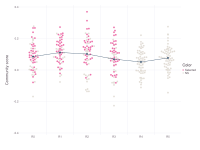

In [7]:
set_default_plot_size(20cm, 15cm)

selectedAlgorithm1 = plot(
        layer(x = colnames, y = mean(A, dims = 1), Geom.point, Geom.line, alpha = [1],
        size = [1mm], color = [colorant"#223F5D"]),
    
        layer(
        x = selectedOne.R,
        y = selectedOne.Value,
        color = selectedOne.Selection, 
        Geom.beeswarm),

        Guide.xlabel(" "),
        Guide.ylabel("Community score"),
        Scale.color_discrete_manual("#ED71AA", "#E2DDD6", "#82CA70"),
        Theme(default_color = "#D990B4", highlight_width = 0.5pt,
          continuous_highlight_color = _ -> "white"))


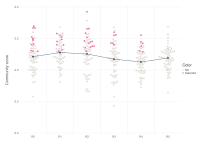

In [8]:
selectedAlgorithm2 = plot(
        layer(x = colnames, y = mean(A, dims = 1), Geom.point, Geom.line, alpha = [1],
        size = [1mm], color = [colorant"#223F5D"]),
    
        layer(
        x = selectedOne.R,
        y = selectedOne.Value,
        color = METACombinations.SelectedforR5, 
        Geom.beeswarm),

        Guide.xlabel(" "),
        Guide.ylabel("Community score"),
        Scale.color_discrete_manual("#E2DDD6", "#ED71AA", "#82CA70"),
        Theme(default_color = "#D990B4", highlight_width = 0.5pt,
          continuous_highlight_color = _ -> "white"))


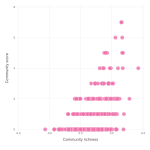

In [9]:
set_default_plot_size(15cm, 15cm)

lenscomm = plot(
    layer(METACombinations,
        x = METACombinations.CommunityScore,
        y = METACombinations.LRS,
        Geom.point,
        alpha = [0.8],
        size  = [2mm],
        color = [colorant"#ED71AA"]),
        Guide.xticks(ticks = [-0.4, -.2, 0, 0.2, 0.4]),
        Guide.yticks(ticks = collect(0:2:8)),

    Guide.xlabel("Community richness"),
    Guide.ylabel("Community score"),
    Theme(highlight_width = 0.5pt, continuous_highlight_color = _ -> "white"))


#draw(PDF("CommunityScore-Richness.pdf", 20cm, 12cm), lenscomm)

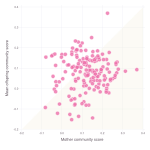

In [10]:
motheroffspringcorrelation = plot(
    layer(plotdf,
        x = :MotherScore,
        y = :OffspringAvgScore,
        Geom.point,
        alpha = [0.8],
        size  = [2mm],
        color = [colorant"#ED71AA"]),
          
    layer(
        x = [-0.2, 0.4, 0.4],
        y = [-0.2, 0.4, -0.2],
        Geom.polygon(fill=true),
        Theme(default_color = colorant"#fefbf0"),
        alpha = [0.15]
        ),

    Guide.xlabel("Mother community score"),
    Guide.ylabel("Mean offspring community score"))

In [11]:
sort(METACombinations, [:LRS]) ;

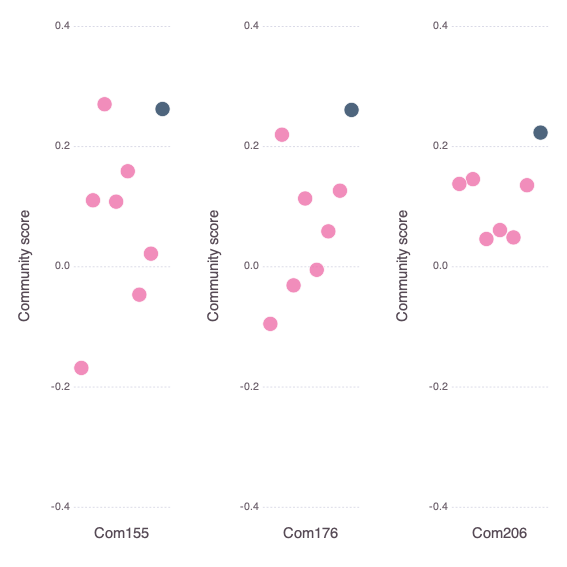

In [12]:
mother155 = plotMotherOffspringScores(METACombinations, 155)
mother176 = plotMotherOffspringScores(METACombinations, 176)
mother206 = plotMotherOffspringScores(METACombinations, 206)

hstack(mother155, mother176, mother206)

### Pairwise score differences across mutation distance

In [13]:
METACombinations.Members = [parse.(Int, split(METACombinations.Members[i], ", ")) for i in 1:length(METACombinations.Members)]

n = length(METACombinations.Members)
D = Matrix{Int}(undef, n, n)
F = Matrix{Float64}(undef, n, n)

for i in eachindex(METACombinations.Members), j in eachindex(METACombinations.Members)
    D[i, j] = mutationDistance(METACombinations.Members[i], METACombinations.Members[j])
    F[i, j] = abs(METACombinations.CommunityScore[i] - METACombinations.CommunityScore[j])
end

n = nrow(METACombinations)

pairs = DataFrame(
    Community1 = [],
    Community2 = [],
    Fitness1 = Float64[],
    Fitness2 = Float64[],
    Distance = Int[],
    FitnessDifference = Float64[]
)

for i in 1:n
    for j in (i+1):n #No self relationship
        push!(pairs, (
            METACombinations.CommunityID[i],
            METACombinations.CommunityID[j],
            METACombinations.CommunityScore[i],
            METACombinations.CommunityScore[j],
            D[i, j],
            F[i, j]
        ))
    end
end

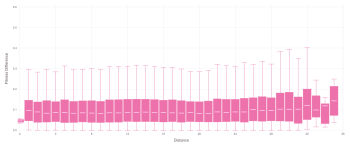

In [14]:
set_default_plot_size(35cm, 15cm)

boxpair = plot(
    pairs,
    x = :Distance,
    y = :FitnessDifference,
    Geom.boxplot(suppress_outliers = true), 
    Guide.xticks(ticks = collect(0:4:37)),
    Guide.xlabel("Distance"),
    Guide.ylabel("Fitness Difference"),
    Theme(default_color = colorant"#ED71AA"),
)

### Validation experiment of community scores

In [15]:
#| code-summary: "Getting "

noise = CSV.read("Disassembly_Validation_Normalized_FD_Results.csv", DataFrame)

noise1 = noise[noise.Sampling .== 1, :]
noise2 = noise[noise.Sampling .== 2, :]
noise3 = noise[noise.Sampling .== 3, :]
noise4 = noise[noise.Sampling .== 4, :]

noise14 = vcat(noise1, noise4)

# Mean and variance per Community
community_summary = combine(
    groupby(noise4, :CommunityID),
    :deg_vs_blank => mean => :mean_deg_vs_blank,
    :deg_vs_blank => var  => :var_deg_vs_blank
)

sort(community_summary.var_deg_vs_blank)[end] 
;

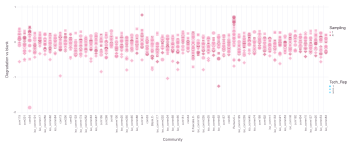

In [16]:
set_default_plot_size(35cm, 15cm)

noisePlot = plot(noise14,
    x = :CommunityID,
    y = :deg_vs_blank,
    color = :Sampling,
    shape = :Tech_Rep,
    Geom.point,
    size = [2mm],
    alpha = [0.7],
    Scale.color_discrete_manual(pinks...),
    Guide.xlabel("Community"),
    Guide.ylabel("Degradation vs blank")
)